In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import numpy as np

In [2]:
O_TRAIN  = r"C:\Users\abiga\OneDrive\Desktop\ML\O_Fe_training_data.csv"
NA_TRAIN = r"C:\Users\abiga\OneDrive\Desktop\ML\Na_Fe_training_data.csv"

train_o = pd.read_csv(O_TRAIN)
train_na = pd.read_csv(NA_TRAIN)

In [3]:
train_o = train_o.copy()

train_o["FeH_used"] = train_o["Fe/H"].fillna(train_o["Fe/H_o"])

cutoffs = {'F275W_abs': 8.5, 'F336W_abs': 6., 'F438W_abs': 6., 'F606W_abs': 4., 'F814W_abs': 3.}

for band, cutoff in cutoffs.items():
    train_o = train_o[train_o[band] <= cutoff]

train_o["c1"] = train_o["F275W_abs"] - train_o["F336W_abs"]
train_o["c2"] = train_o["F336W_abs"] - train_o["F438W_abs"]
train_o["c3"] = train_o["F438W_abs"] - train_o["F606W_abs"]
train_o["c4"] = train_o["F606W_abs"] - train_o["F814W_abs"]

feature_cols_o = ["c1", "c2", "c3", "c4", "age_Kruijssen", "FeH_used"]
target_col_o = "O/Fe"

train_o = train_o.dropna(subset=feature_cols_o + [target_col_o])

In [4]:
train_na = train_na.copy()

train_na["FeH_used"] = train_na["Fe/H"].fillna(train_na["Fe/H_o"])

cutoffs = {'F275W_abs': 8.5, 'F336W_abs': 6., 'F438W_abs': 6., 'F606W_abs': 4., 'F814W_abs': 3.}

for band, cutoff in cutoffs.items():
    train_na = train_na[train_na[band] <= cutoff]

train_na["c1"] = train_na["F275W_abs"] - train_na["F336W_abs"]
train_na["c2"] = train_na["F336W_abs"] - train_na["F438W_abs"]
train_na["c3"] = train_na["F438W_abs"] - train_na["F606W_abs"]
train_na["c4"] = train_na["F606W_abs"] - train_na["F814W_abs"]

feature_cols_na = ["c1", "c2", "c3", "c4", "age_Kruijssen", "FeH_used"]
target_col_na = "Na/Fe"

train_na = train_na.dropna(subset=feature_cols_na + [target_col_na])

In [5]:
target_col_o = "O/Fe"

X_train_o = train_o[feature_cols_o]
y_train_o = train_o[target_col_o]

In [6]:
target_col_na = "Na/Fe"

X_train_na = train_na[feature_cols_na]
y_train_na = train_na[target_col_na]


In [7]:
from sklearn.model_selection import train_test_split

X_train_o, X_val_o, y_train_o, y_val_o = train_test_split(
    X_train_o, y_train_o, test_size=0.2, random_state=42
)

degrees = [1, 2, 3, 4]
alphas = [0.01, 0.1, 1, 10, 100, 1000]

best_rmse_o = float("inf")
best_config_o = None

for d in degrees:
    for a in alphas:
        model = Pipeline([
            ("scaler", MinMaxScaler(feature_range=(-1, 1))),
            ("poly", PolynomialFeatures(degree=d, include_bias=False)),
            ("ridge", Ridge(alpha=a))
        ])

        model.fit(X_train_o, y_train_o)
        y_pred_o = model.predict(X_val_o)

        rmse_o = np.sqrt(mean_squared_error(y_val_o, y_pred_o))

        if rmse_o < best_rmse_o:
            best_rmse_o = rmse_o
            best_config_o = (d, a)

print("Best RMSE:", best_rmse_o)
print("Best degree, alpha:", best_config_o)


Best RMSE: 0.19862655137641988
Best degree, alpha: (4, 0.1)


In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

model_o = Pipeline([
    ("scaler", MinMaxScaler(feature_range=(-1, 1))),
    ("poly", PolynomialFeatures(degree=best_config_o[0], include_bias=False)),
    ("ridge", Ridge(alpha=best_config_o[1]))
])

model_o.fit(X_train_o, y_train_o)
y_pred_o = model_o.predict(X_val_o)

rmse_o = np.sqrt(mean_squared_error(y_val_o, y_pred_o))
r2_o = r2_score(y_val_o, y_pred_o)

print("RMSE =", rmse_o)
print("R^2 =", r2_o)

RMSE = 0.19862655137641988
R^2 = 0.6149622391896952


In [9]:
from sklearn.model_selection import train_test_split

X_train_na, X_val_na, y_train_na, y_val_na = train_test_split(
    X_train_na, y_train_na, test_size=0.2, random_state=42
)

degrees = [1, 2, 3, 4]
alphas = [0.01, 0.1, 1, 10, 100, 1000]

best_rmse_na = float("inf")
best_config_na = None

for d in degrees:
    for a in alphas:
        model = Pipeline([
            ("scaler", MinMaxScaler(feature_range=(-1, 1))),
            ("poly", PolynomialFeatures(degree=d, include_bias=False)),
            ("ridge", Ridge(alpha=a))
        ])

        model.fit(X_train_na, y_train_na)
        y_pred_na = model.predict(X_val_na)

        rmse_na = np.sqrt(mean_squared_error(y_val_na, y_pred_na))

        if rmse_na < best_rmse_na:
            best_rmse_na = rmse_na
            best_config_na = (d, a)

print("Best RMSE:", best_rmse_na)
print("Best degree, alpha:", best_config_na)

Best RMSE: 0.21025551974858514
Best degree, alpha: (3, 1)


In [10]:
model_na = Pipeline([
    ("scaler", MinMaxScaler(feature_range=(-1, 1))),
    ("poly", PolynomialFeatures(degree=best_config_na[0], include_bias=False)),
    ("ridge", Ridge(alpha=best_config_na[1]))
])

model_na.fit(X_train_na, y_train_na)
y_pred_na = model_na.predict(X_val_na)

rmse_na = np.sqrt(mean_squared_error(y_val_na, y_pred_na))
r2_na = r2_score(y_val_na, y_pred_na)

print("R^2 =", r2_na)
print("RMSE =", rmse_na)

R^2 = 0.4157332933613933
RMSE = 0.21025551974858514


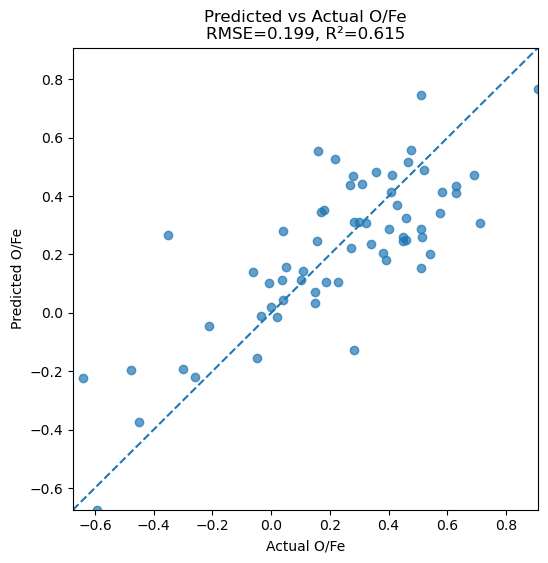

In [11]:
plt.figure(figsize=(6, 6))
plt.scatter(y_val_o, y_pred_o, alpha=0.7)

min_val = min(y_val_o.min(), y_pred_o.min())
max_val = max(y_val_o.max(), y_pred_o.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Actual O/Fe")
plt.ylabel("Predicted O/Fe")
plt.title(f"Predicted vs Actual O/Fe\nRMSE={rmse_o:.3f}, R²={r2_o:.3f}")
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.show()

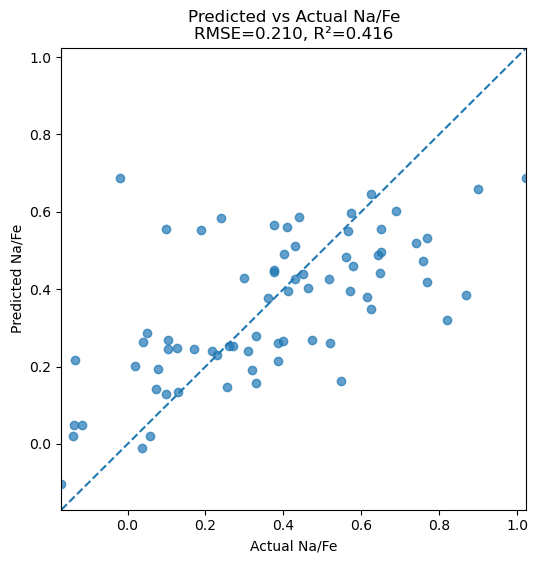

In [12]:
plt.figure(figsize=(6, 6))
plt.scatter(y_val_na, y_pred_na, alpha=0.7)

min_val = min(y_val_na.min(), y_pred_na.min())
max_val = max(y_val_na.max(), y_pred_na.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Actual Na/Fe")
plt.ylabel("Predicted Na/Fe")
plt.title(f"Predicted vs Actual Na/Fe\nRMSE={rmse_na:.3f}, R²={r2_na:.3f}")
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.show()

In [13]:
poly_o = model_o.named_steps["poly"]
ridge_o = model_o.named_steps["ridge"]

feature_names_o = poly_o.get_feature_names_out(feature_cols_o)
coefficients_o = ridge_o.coef_

coef_data_o = [(name, coef, abs(coef)) for name, coef in zip(feature_names_o, coefficients_o)]

coef_data_o_sorted = sorted(coef_data_o, key=lambda x: x[2], reverse=True)

print("Intercept:", ridge_o.intercept_)
print("\nFeature Importance (sorted):")

for name, coef, abs_coef in coef_data_o_sorted:
    print(f"{name}: {coef:.5f}")

Intercept: 0.08411601794216397

Feature Importance (sorted):
c1: 1.29272
c4: 0.76874
c2: -0.76011
c2^2: 0.65600
age_Kruijssen FeH_used: 0.61362
c2 age_Kruijssen: -0.53387
c1 FeH_used: -0.52728
c2 age_Kruijssen^3: 0.50794
c4^2 age_Kruijssen: -0.47707
c3: -0.47606
c3 c4 age_Kruijssen: -0.45743
c1 c2: 0.43362
c2 c3: 0.41284
c4^2 age_Kruijssen^2: 0.40706
c3^3: 0.40654
c1^2 FeH_used: -0.39812
c1 c3^2: 0.39639
c1^2: 0.37685
c1^2 age_Kruijssen FeH_used: -0.37489
FeH_used^2: -0.36995
c1 c2 age_Kruijssen: 0.36733
c4^3 age_Kruijssen: 0.36108
c4 FeH_used^2: -0.33964
c4^2: -0.33759
c2^2 FeH_used: -0.33206
c4 age_Kruijssen^2 FeH_used: 0.32563
c1^2 age_Kruijssen^2: 0.31295
c4 FeH_used: 0.30783
c4 age_Kruijssen FeH_used^2: -0.30512
c1 age_Kruijssen: -0.30163
c1^3 c2: 0.29798
c2^4: -0.29425
age_Kruijssen^3: 0.28157
c3 c4: 0.27976
c1 age_Kruijssen FeH_used^2: -0.27528
c1 age_Kruijssen^2: 0.27468
age_Kruijssen^2: -0.27116
c4 age_Kruijssen^2: -0.26949
c2^3: -0.26875
c4^2 FeH_used: -0.26484
c3^4: -0.26459

In [14]:
total = sum(abs_coef for _, _, abs_coef in coef_data_o_sorted)

for name, coef, abs_coef in coef_data_o_sorted:
    importance = abs_coef / total
    print(f"{name}: {coef:.5f} (importance: {importance:.3f})")

c1: 1.29272 (importance: 0.040)
c4: 0.76874 (importance: 0.024)
c2: -0.76011 (importance: 0.023)
c2^2: 0.65600 (importance: 0.020)
age_Kruijssen FeH_used: 0.61362 (importance: 0.019)
c2 age_Kruijssen: -0.53387 (importance: 0.016)
c1 FeH_used: -0.52728 (importance: 0.016)
c2 age_Kruijssen^3: 0.50794 (importance: 0.016)
c4^2 age_Kruijssen: -0.47707 (importance: 0.015)
c3: -0.47606 (importance: 0.015)
c3 c4 age_Kruijssen: -0.45743 (importance: 0.014)
c1 c2: 0.43362 (importance: 0.013)
c2 c3: 0.41284 (importance: 0.013)
c4^2 age_Kruijssen^2: 0.40706 (importance: 0.013)
c3^3: 0.40654 (importance: 0.013)
c1^2 FeH_used: -0.39812 (importance: 0.012)
c1 c3^2: 0.39639 (importance: 0.012)
c1^2: 0.37685 (importance: 0.012)
c1^2 age_Kruijssen FeH_used: -0.37489 (importance: 0.012)
FeH_used^2: -0.36995 (importance: 0.011)
c1 c2 age_Kruijssen: 0.36733 (importance: 0.011)
c4^3 age_Kruijssen: 0.36108 (importance: 0.011)
c4 FeH_used^2: -0.33964 (importance: 0.010)
c4^2: -0.33759 (importance: 0.010)
c2^2

In [15]:
poly_na = model_na.named_steps["poly"]
ridge_na = model_na.named_steps["ridge"]

feature_names_na = poly_na.get_feature_names_out(feature_cols_na)
coefficients_na = ridge_na.coef_

# Pair feature name, coefficient, and absolute value
coef_data_na = [(name, coef, abs(coef)) for name, coef in zip(feature_names_na, coefficients_na)]

# Sort by absolute value (largest → smallest)
coef_data_na_sorted = sorted(coef_data_na, key=lambda x: x[2], reverse=True)

print("Intercept:", ridge_na.intercept_)
print("\nFeature Importance (sorted):")

for name, coef, abs_coef in coef_data_na_sorted:
    print(f"{name}: {coef:.5f}")

Intercept: 0.46378141391822014

Feature Importance (sorted):
c2: 0.56767
c1: -0.56643
c2^2: -0.44086
c2 c3: -0.37985
c2 c4: -0.28503
c1 c3: 0.25177
c2 age_Kruijssen^2: 0.25087
c2 FeH_used: 0.23776
c1 FeH_used: 0.23274
c2^2 c3: 0.22454
c3 age_Kruijssen: 0.21727
c4 age_Kruijssen: 0.21409
c4 FeH_used: -0.19912
age_Kruijssen: 0.19598
c2 c3^2: 0.18828
c2^2 FeH_used: 0.18719
c4^2: 0.17903
c1 FeH_used^2: -0.15562
c1^3: -0.15128
c2^3: 0.14306
c2 c4 age_Kruijssen: 0.13985
c1 c3^2: -0.13904
c2 c3 c4: 0.13791
c2^2 c4: 0.13665
c4: -0.12338
age_Kruijssen^3: 0.12331
c2 c3 age_Kruijssen: 0.12256
FeH_used^2: 0.12222
c1 c3 FeH_used: -0.12022
c3 FeH_used: -0.11524
age_Kruijssen FeH_used: -0.11104
c3 c4 FeH_used: 0.10919
c1 c2 FeH_used: 0.10909
c1 c4: 0.10877
c1 c4 FeH_used: -0.10865
c3 c4^2: -0.10769
c3^2 FeH_used: 0.10669
c2 c4^2: 0.10530
c4 FeH_used^2: -0.08727
c1^2 c2: -0.08577
c1 age_Kruijssen^2: -0.08521
c3^2 c4: -0.08480
c4^2 FeH_used: 0.08367
c1 c3 c4: -0.08234
c1^2 c4: -0.08219
c3^2 age_Kruijsse

In [16]:
total = sum(abs_coef for _, _, abs_coef in coef_data_na_sorted)

for name, coef, abs_coef in coef_data_na_sorted:
    importance = abs_coef / total
    print(f"{name}: {coef:.5f} (importance: {importance:.3f})")

c2: 0.56767 (importance: 0.060)
c1: -0.56643 (importance: 0.060)
c2^2: -0.44086 (importance: 0.047)
c2 c3: -0.37985 (importance: 0.040)
c2 c4: -0.28503 (importance: 0.030)
c1 c3: 0.25177 (importance: 0.027)
c2 age_Kruijssen^2: 0.25087 (importance: 0.027)
c2 FeH_used: 0.23776 (importance: 0.025)
c1 FeH_used: 0.23274 (importance: 0.025)
c2^2 c3: 0.22454 (importance: 0.024)
c3 age_Kruijssen: 0.21727 (importance: 0.023)
c4 age_Kruijssen: 0.21409 (importance: 0.023)
c4 FeH_used: -0.19912 (importance: 0.021)
age_Kruijssen: 0.19598 (importance: 0.021)
c2 c3^2: 0.18828 (importance: 0.020)
c2^2 FeH_used: 0.18719 (importance: 0.020)
c4^2: 0.17903 (importance: 0.019)
c1 FeH_used^2: -0.15562 (importance: 0.017)
c1^3: -0.15128 (importance: 0.016)
c2^3: 0.14306 (importance: 0.015)
c2 c4 age_Kruijssen: 0.13985 (importance: 0.015)
c1 c3^2: -0.13904 (importance: 0.015)
c2 c3 c4: 0.13791 (importance: 0.015)
c2^2 c4: 0.13665 (importance: 0.015)
c4: -0.12338 (importance: 0.013)
age_Kruijssen^3: 0.12331 (i